# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd             # librería de pandas, útil en la siguiente línea para importar los archivos csv con los que se trabajará
import numpy as np              # librería de numpy
import matplotlib.pyplot as plt # librería de matplotlib para poder crear los histogramas con el módulo pyplot
import seaborn as sns           # Librería de seaborn para graficos

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("datasets/usage.csv")

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("Número de filas y columnas de cada dataset:")
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

Número de filas y columnas de cada dataset:
plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("=" * 60)
print("Cantidad de valores nulos\n", users.isna().sum().sort_values(ascending=False))
print("=" * 60)
print("Proporción de valores nulos\n", users.isna().mean().sort_values(ascending=False))
print("=" * 60)

Cantidad de valores nulos
 churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64
Proporción de valores nulos
 churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("=" * 60)
print("Cantidad de valores nulos\n", usage.isna().sum().sort_values(ascending=False))
print("=" * 60)
print("Proporción de valores nulos \n", usage.isna().mean().sort_values(ascending=False))
print("=" * 60)

Cantidad de valores nulos
 duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64
Proporción de valores nulos 
 duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

## Las columnas con tienen valores faltantes son: Churn, City, Duration, Length y date

- Los datos estadísticos muestran que: **churn_date** tiene 88% de nulos, normalmente se recomendaría eliminar la columna, pero no es el caso, debido a la naturaleza del dato, que nos indica los clientes que han cancelado, entonces los nulos son clientes con contrato activo.
- Los datos estadísticos muestran que: **city** tiene 11% de nulos, se sugiere investigar para ver la viabilidad de dejarlos como "unknown", ademas en la exploracion se vieron datos como "?", que tambien deben pasarse a "unknown"
- Los datos estadísticos muestran que: **duration** tiene 55% de nulos, "duration" almacena la duración de las llamadas, se debe investigar si la razón de los nulos está relacionado con la columna length, si la persona no llama entonces escribe mensaje, si esto es así, entonces hay que conservar la columna y comparar tambien si cuando hay nulos  es porque "Type" es igual a "text"
- Los datos estadísticos muestran que: **length** tiene 44% de nulos, "length" es la cantidad de caracteres de texto en un mensaje, se debe investigar si la razón de los nulos está relacionado con la columna duration, si la persona no escribe mensaje entonces hizo una llamada, si esto es así, hay que conservar la columna y comparar tambien si cuando hay nulos es porque "Type" es igual a "call"
- Los datos estadísticos muestran que: **date** tiene 0.1% de nulos, el porcentaje es muy bajo, se sugiere dejar como nulos o eliminar las filas, debido a que es un porcentaje tan bajo que no afectaria al resultado final.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print("Resumen estadístico de user_id y age:\n",users[["user_id","age"]].describe())
print("=" * 60)
print("Menores de edad:",users["age"].between(0, 17).sum())
print("Edades negativas:",users["age"].lt(0).sum())
print("Los valores en el indice user_id ¿son unicos?:", users["user_id"].is_unique)
print("=" * 60)

Resumen estadístico de user_id y age:
             user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
Menores de edad: 0
Edades negativas: 55
Los valores en el indice user_id ¿son unicos?: True


- La columna `user_id` es un índice con valores únicos, que inicia en 10000y termina en 13999 (4000 usuarios)
- La columna `age` tiene 55 valores negativos inválidos, no hay menores de edad y la edad máxima es 79 años

In [ ]:
# explorar columnas numéricas de usage
print("=" * 60)
print("Resumen estadístico de id y user_id:\n",usage[["id","user_id"]].describe())
print("=" * 60)
print("Los valores en el indice id ¿son unicos?:", usage["id"].is_unique)
print("=" * 60)
print("Resumen estadístico de duration y length:\n",usage[["duration","length"]].describe())
print("=" * 60)

Resumen estadístico de id y user_id:
                 id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000
Los valores en el indice id ¿son unicos?: True
Resumen estadístico de duration y length:
            duration        length
count  17924.000000  22104.000000
mean       5.202237     52.127398
std        6.842701     56.611183
min        0.000000      0.000000
25%        1.437500     37.000000
50%        3.500000     50.000000
75%        6.990000     64.000000
max      120.000000   1490.000000


- Las columnas `id` y `user_id`
  -  "id" es el índice de usage; no hay duplicados; para 40000 registros, inicia en 1 y termina en 40000; indica que no hay valores inválidos.
  -  "user_id" los valores están muy dispersos, valores entre 10000 y 13999, consistente con el rango de valores en el indice de la tabla users
- Las columnas duration y lenght, sus registros suman 40,028, si el dataset tiene un total de 40,000 registros, entonces hay 28 anomalias que deben ser revisadas, posiblemente errores donde una fila tiene registro para length y duration, se validara con type si el error esta en lenght o duration.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
# users[columnas_user].head(10)
print("=" * 60)
for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].unique())   # como ya sabemos con la funcion unique, obtenemos los valores diferentes
print("=" * 60)
for col in columnas_user:
    print(f"\nFrecuencia de valores en {col}:")
    print(users[col].value_counts(dropna=False))   # la funcion value counts, cuenta los frecuencia de cada valor distinto en el data frame, con dropna incluimos los nulos
print("=" * 60)


Valores únicos en city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos en plan:
['Basico' 'Premium']

Frecuencia de valores en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Frecuencia de valores en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene 469 valores nulos y 96 registros sin ciudad con el signo "?"
- Bogotá es la ciudad con mayor frecuencia (808 usuarios) y MTY con menor frecuencia (407 usuarios)
- La columna `plan` solo tiene dos valores: Basico y Premium, lo cual es consistente con el data frame plans

In [ ]:
# explorar columna categórica de usage
print("=" * 60)
print("Valores unicos", usage['type'].unique())
print("=" * 60)
print("Frecuencia de valores unicos:\n",usage["type"].value_counts(dropna=False))
print("=" * 60)
print("Porcentaje de tipos de uso:\n",usage["type"].value_counts(normalize=True)) # con normalize en lugar de obtener el conteo de cada valor, obtenemos la proporción
print("=" * 60)

Valores unicos ['call' 'text']
Frecuencia de valores unicos:
 text    22092
call    17908
Name: type, dtype: int64
Porcentaje de tipos de uso:
 text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` solo tiene los valores "call" y "text"
- 55% del uso son mensajes de texto y el 44% restante llamadas telefonicas
- Lo que no podemos ver y seria muy importante para upgrades o nuevos planes, seria el uso de los datos.

---
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    - La columna `age` tenia 55 valores negativos inválidos
    - Las columnas `duration` y `lenght`, sus registros suman 40,028, si el dataset tiene un total de 40,000 registros, entonces hay 28 anomalias que deben ser revisadas, posiblemente errores donde una fila tiene registro para length y duration, se validará con type si el error esta en lenght o duration.
    - La columna `city` tenia 96 registros sin ciudad con el signo "?"

- ¿Qué acción tomarías?
  - `age`: reemplazar nulos con la mediana de la edad
  - `duration` y `lenght`, convertir a nulo el campo contrario a valor en "type", es decir si "type" es igual a "text", entonces convertir "duration" en nulo
  - `city`: reemplazar "?" con "unknown"


# Valores inválidos o sentinels encontrados
- La columna `age` tiene 55 valores negativos inválidos (menos del 2% de los registros), no hay menores de edad y la edad máxima es 79 años, se sugiere reemplazar los valores negativos por nulos, después considerar reemplazarlos por la media o la mediana
- La columna `city` tiene 469 valores nulos y 96 registros sin ciudad con el signo "?" (suman el 14% de los registros), se sugiere reemplazar ambos por "unknown"
- Las columnas `duration` y `lenght`, sus registros suman 40,028, si el dataset tiene un total de 40,000 registros, entonces hay 28 anomalias que deben ser revisadas, posiblemente errores donde una fila tiene registro para length y duration, se validará con type si el error esta en lenght o duration, de ser asi entonces: convertir a nulo el campo contrario a valor en type, es decir si type es igual a "text", entonces convertir el valor de "duration" en nulo

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"]=pd.to_datetime(users["reg_date"], errors="coerce", utc=True)
print("formato de reg_date:",users["reg_date"].dtype)

formato de reg_date: datetime64[ns, UTC]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce", utc=True)
print("formato de date:",usage["date"].dtype)

formato de date: datetime64[ns, UTC]


In [ ]:
# Revisar los años presentes en `reg_date` de users
print("=" * 60)
print("Años presentes en reg_date\n",users["reg_date"].dt.year.unique())
print("=" * 60)
print("Cuantas veces aparece cada año \n",users["reg_date"].dt.year.value_counts(dropna=False))
print("=" * 60)
#print("\nRevisamos año 2026",users.loc[users["reg_date"].dt.year == 2026, "reg_date"])

Años presentes en reg_date
 [2022 2026 2023 2024]
Cuantas veces aparece cada año 
 2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, encontramos los años del 2022 al 2024, y cuarenta registros invalidos con año 2026 que representan el 1% de los registros, debido a que solo estamos trabajando con fechas hasta el año 2024

In [ ]:
# Revisar los años presentes en `date` de usage
print("Años presentes en date\n", usage["date"].dt.year.unique())
print("\ncuantas veces aparece cada año\n", usage["date"].dt.year.value_counts(dropna=False))

Años presentes en date
 [2024.   nan]

cuantas veces aparece cada año
 2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, únicamente tiene el año 2024 y menos del 1% en nulos
Basaremos el análisis en estas fechas.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  - En reg_date, (fecha de reistro) encontramos cuarenta registros invalidos con año 2026 que representan el 1% de los registros
  - en date (fecha de uso del servicio) encontramos 50 valores nulos (menos del 1% de registros)
- ¿Qué harías con ellas?
Descartarlos para calculos relacionados con las fechas.

**Diagnóstico y acciones recomendadas**

-  En el caso de la fecha de registro (reg_date) va del año 2022 al 2024 y existen cuarenta registros inválidos del año 2026, que representan el 1% de los registros, estas fechas están fuera del rango esperado (hasta el 2024), se recomienda convertirlos a NaT para posteriormente excluirlos de cálculos relacionados con fechas
-  En el caso de la fecha de uso (date), únicamente hay registros del año 2024 con menos del 1% de valores nulos, se recomienda excluirlos de calculos relacionados con fechas



---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
# age_mediana = users["age"].median() Calculamos la mediana y la almacenamos en age_mediana, lo cual seria correcto si no tuvieramos valores negativos.
age_mediana = users.loc[users["age"] > 0, "age"].median() # filtramos los valores mayores a cero y luego sacamos la mediana
users["age"]=users["age"].replace(-999, pd.NA) # Reemplazamos sentinels numéricos por valor faltante en pandas
users["age"]=users["age"].fillna(age_mediana) # Reemplazamos los nulos por la mediana
print("Se reemplazan fechas inválidas y se muestra un resumen estadístico para validar")
# Verificar cambios
users['age'].describe()

Se reemplazan fechas inválidas y se muestra un resumen estadístico para validar


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace("?", pd.NA)
print("Se reemplazan ciudades con ?, y se muestra una lista de valores únicos y su frecuencia\n")
# Verificar cambios
print("validación de cambios\n",users["city"].value_counts(dropna=False))

Se reemplazan ciudades con ?, y se muestra una lista de valores únicos y su frecuencia

validación de cambios
 Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT
# En el data frame users
# ubicamos la columna "reg_Date"
# para todos los registros donde reg_date es mayor al año 2024
# se crea un lista booleana donde los aciertos se reemplazan por not a time
print("Se reemplazan fechas inválidas por NaT y se muestra lista de valores únicos y su frecuencia")
# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False)

Se reemplazan fechas inválidas por NaT y se muestra lista de valores únicos y su frecuencia


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**

- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("=" * 60)
print("Diagnóstico de valores nulos en duration por tipo de uso (call/text)")
print(
usage.groupby("type")["duration"].agg(     # Agrupamos por type, que tiene dos valores posibles, text y call, además seleccionamos la columna duración de llamada
    total_registros="size",                # cuenta todos los registros del grupo, incluyendo valores nulos en duration, por tipo llamada y mensajes (datos agrupados)
    valores_no_nulos="count",              # cuenta solo valores no nulos
    valores_nulos=lambda x: x.isna().sum() # marca los valores nulos y luego los suma
))
print("=" * 60)
print("Registros donde type vale text y tienen valores en length y duration\n")
text_con_duration = usage[(usage["type"] == "text") & (usage["duration"].notna())]
print(text_con_duration[["id","type","length","duration"]].head(5))
print("=" * 60)


Diagnóstico de valores nulos en duration por tipo de uso (call/text)
      total_registros  valores_no_nulos  valores_nulos
type                                                  
call            17908             17908            0.0
text            22092                16        22076.0
Registros donde type vale text y tienen valores en length y duration

          id  type  length  duration
1414    1415  text    65.0     120.0
1824    1825  text    40.0     120.0
1932    1933  text    69.0     120.0
2972    2973  text    68.0     120.0
11456  11457  text    23.0     120.0


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("=" * 60)
print("Diagnóstico de valores nulos en lenghtn por tipo de uso (call/text)")
print(
    usage.groupby("type")["length"].agg(       # Agrupamos por type, que tiene dos valores posibles, text y call, además seleccionamos la columna longitud del mensaje
        total_registros="size",                # cuenta todos los registros del grupo, incluyendo valores nulos en longitud, por tipo de llamada y mensaje (datos agrupados)
        valores_no_nulos="count",              # cuenta solo los valores nulos
        valores_nulos=lambda x: x.isna().sum() # marca los valores nulos y luego los suma
    )
)
print("=" * 60)
print("Registros donde type vale call y tienen valores en longitud del texto")
call_con_length= usage[(usage["type"]=="call")&(usage["length"].notna())]
print(call_con_length[["id","type","duration","length"]].head(5))
print("=" * 60)

Diagnóstico de valores nulos en lenghtn por tipo de uso (call/text)
      total_registros  valores_no_nulos  valores_nulos
type                                                  
call            17908                12        17896.0
text            22092             22092            0.0
Registros donde type vale call y tienen valores en longitud del texto
          id  type  duration  length
2070    2071  call      1.68  1490.0
5272    5273  call      3.78  1490.0
10614  10615  call      0.53  1490.0
12692  12693  call      1.80  1490.0
16910  16911  call      3.29  1490.0


Los valores nulos en duration y length `no son aleatorios`, porque su ausencia está estructuralmente determinada por el atributo "type", cuando este tiene el valor "text" entonces debe haber un nulo en "duration" y cuando tiene el valor "call" entonces debe haber un nulo en "length"

**Diagnóstico de nulos en duración de llamadas y longitud de mensajes de texto**

Las columnas duración de la llamada (duration) y longitud del mensaje de texto (length), están directamente relacionadas con la columna tipo (type) de uso del teléfono.
Si el tipo de uso es llamada (call) entonces se espera encontrar un valor en duración de la llamada (duration) y un valor nulo en longitud del texto.
Si el tipo de uso es texto (text) entonces se espera encontrar un valor en longitud del mensaje de texto (length) y un valor nulo en duración de la llamada

-  duration:  No se encontraron valores nulos en los casos que "type" tiene el valor de "call", sin embargo hay una anomalia de 16 registros donde "duration" tiene un valor de 120 segundos cuando "type" tiene el valor de "text", se revisaron y tambien tienen valor en "length", por lo cual se determina que es un mensaje de texto, se sugiere conservar las filas y reemplazar por NaN/nulo esos valores en duration.
-  length: No se encontraron valores nulos en los casos que "type" tiene el valor de "text", sin embargo hay una anomalia de 12 registros donde "lenght" tiene un valor de 1490 caracteres cuando "type" tiene el valor de "call", se revisaron y tambien un valor en "duration", por lo cual se determina que es una llamada telefonica, se sugiere conservar las filas y reemplazar por NaN/nulo esos valores en length

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes, 1 si es mensaje y 0 si no
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas, 1 si es llamada y 0 si no
#usage.info()

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=["user_id"], how= "inner")
# Combina users con usage_agg usando la columna común user_id, conservando solo los usuarios que existan en ambas tablas.
user_profile.head(5)

#print("Usuarios en users:", users["user_id"].nunique())
#print("Usuarios en usage:", usage["user_id"].nunique())
#print("Usuarios en usage_agg:", usage_agg["user_id"].nunique())
#print("Usuarios en user_profile:", user_profile["user_id"].nunique())
# Al final se no se añadio un usuario con linea activa, pero jamas ha hecho uso de llamadas ni mensajes de texto.
#usuario_perdido = users[~users["user_id"].isin(usage_agg["user_id"])]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
print("Resumen estadístico por usuario durante el 2024")
user_profile.describe()

Resumen estadístico por usuario durante el 2024


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.138285,5.524381,4.478120,23.317054
std,1154.898108,17.691541,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,4.000000,3.000000,11.120000
50%,12000.000000,48.000000,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
#porcentaje_usuarios_basico=(((user_profile["plan"]=="Basico").sum())/(user_profile["plan"].count()))*100
#print("Porcentaje de usuarios en plan Basico:",porcentaje_usuarios_basico)
#porcentaje_usuarios_premium=(((user_profile["plan"]=="Premium").sum())/(user_profile["plan"].count()))*100
#print("Porcentaje de usuarios en plan Premium:", porcentaje_usuarios_premium)
#print("totaldetodo:",porcentaje_usuarios_basico+porcentaje_usuarios_premium)

#otra forma de hacerlo:
print("="*60)
distribucion_plan = (user_profile["plan"] #seleccionamos la columna del plan
    .value_counts                         # usamos la funcion value_counts
    (normalize=True)                      # con esta línea en lugar de obtener el conteo de cada valor, obtenemos la proporción
    .mul(100)                             # multiplica por 100 para tenerlo en base 100
    .round(2)                             # redondeado a dos decimales
                    )
print("Distribución porcentual del tipo de plan:\n",distribucion_plan)
print("="*60)

Distribución porcentual del tipo de plan:
 Basico     64.87
Premium    35.13
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

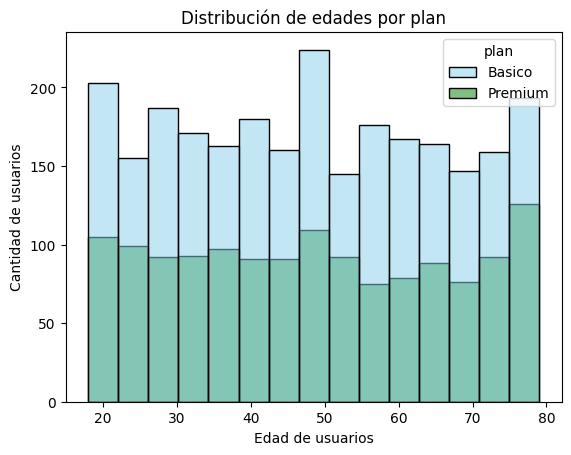

In [ ]:
# Histograma para visualizar la edad (age)
palette=['skyblue','green']

sns.histplot(
    data=user_profile, # seleccionamos data frame user_profile
    x="age",           # se define en el eje X la edad
    hue="plan",        # mostrará la distribución de edades por tipo de plan: básico o premium
    bins=15,           #  √3999 = 63.24 → ≈63 bins, pero seria demasiado a graficar, nos quedaremos con 15 para mejorar la interpretación
    kde=False,         # Solo se mostrarán las barras de histograma sin curva de densidad
    multiple="layer",  # Se superponen distribuciones de cada plan en misma gráfica
    palette=palette    # no usamos "color", porque es una paleta de colores
)

plt.xlabel("Edad de usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de edades por plan")
plt.show()

💡Insights:

- Distribución en el plan básico, se observa bastante simétrica, con tres picos:
   -  Edades de 18-20 años, usuarios jóvenes estudiantes y/o primer empleo
   -  Edades de 78-79 años, adultos mayores con necesidades simples
   -  Edades de 47-48 años, adultos en etapa media de carrera

La distribución del plan básico se comporta de forma similar al plan premium, aunque tiene una mayor cantidad de usuarios, posiblemente atrae perfiles con menor poder adquisitivo o menor necesidad de funciones avanzadas

-  Distribución en el plan premium, se observa simétrica con picos en los extremos:
   -  Edades de 18-20 años, usuarios jóvenes con mayor uso de datos y conectividad y pagan más por ello
   -  Edades de 78-79 años, posiblemente con planes familiares o subsidiados

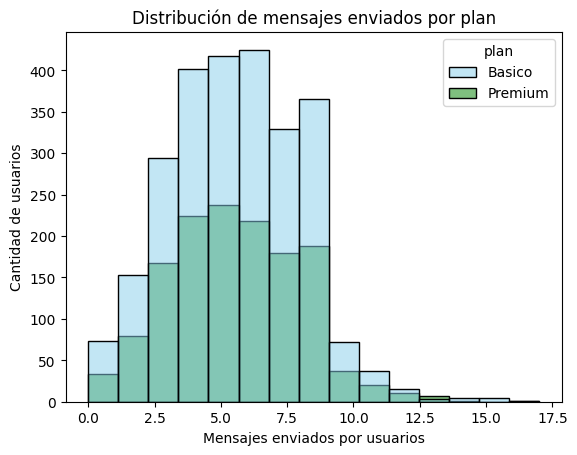

In [ ]:
# Histograma para visualizar la cant_mensajes
palette=["skyblue","green"]
sns.histplot(
    data=user_profile, # seleccionamos el data frame user_profile
    x="cant_mensajes", # se define en el eje X la cantidad de los mensajes
    hue="plan",        # mostrará la distribución de mensajes por tipo de plan
    bins=15,           #  √3999 = 63.24 → ≈63 bins, pero seria demasiado a graficar, nos quedaremos con 15 para mejorar la interpretación
    kde=False,         # Solo se mostrarán las barras de histograma sin curva de densidad
    multiple="layer",  # Se superponen distribuciones de cada plan en la misma gráfica
    palette=palette    # paleta de colores definida al inicio
)
plt.xlabel("Mensajes enviados por usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de mensajes enviados por plan")
plt.show()

💡Insights:

-  Distribución Right-skewed — Debido al límite natural en cero, se esperaba una curva normal o con cola a la derecha, así que la gráfica era esperada y sana estadísticamente.
-  Pico de 4 a 6 mensajes — comportamiento consistente entre planes, lo que sugiere que el plan no influye en el hábito de mensajería.
-  La cantidad de mensajes por usuario esta lejos del límite (17 mensajes el máximo) — esto también cuestiona si el límite de mensajes es un diferenciador de valor percibido real entre planes (100 para básico y 500 para premium)
-  Uso de apps de mensajería, se plantea la hipótesis de que están usando otros servicios de mensajería como whatsapp, Telegram o Pulse que además de texto permiten enviar imágenes o videollamadas
-  Se plantea la hipótesis de que son los adultos mayores los que más usan el servicios de mensajería, por lo tanto habría que cruzar cantidad de mensajes con edades, para ver si los adultos mayores son los que más hacen uso de mensajes por tener menor perfil tecnológico con dispositivos básicos por lo que hacen más uso de los mensajes de texto

De ser correctas las hipótesis planteadas, entonces hay oportunidad de vender upgrade de datos a los usuarios en lugar de cantidad de mensajes de texto

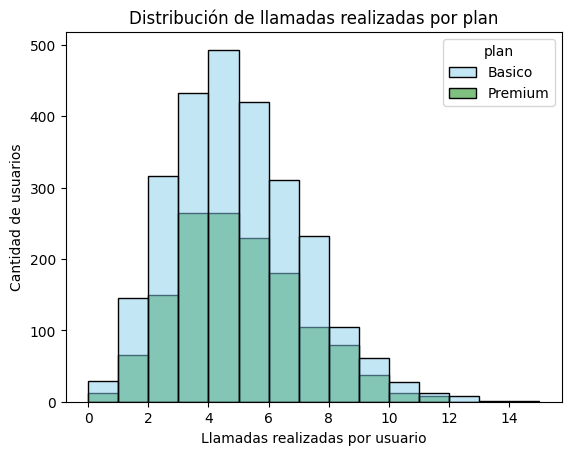

In [ ]:

# Histograma para visualizar la cant_llamadas
palette=["skyblue","green"]
sns.histplot(
    data=user_profile, # seleccionamos el data frame user_profile
    x="cant_llamadas", # se define en el eje X la cantidad de llamadas
    hue="plan",        # mostrará la distribución de mensajes por tipo de plan
    bins=15,           #  √3999 = 63.24 → ≈63 bins, pero seria demasiado a graficar, nos quedaremos con 15 para mejorar la interpretación
    kde=False,         # Solo se mostrarán las barras de histograma sin curva de densidad
    multiple="layer",  # Se superponen distribuciones de cada plan en la misma gráfica
    palette=palette    # paleta de colores definida al inicio
)
plt.xlabel("Llamadas realizadas por usuario")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de llamadas realizadas por plan")
plt.show()



💡Insights:
- Distribución Right-skewed confirmada, cola hasta ~14 llamadas
- Pico de 4 a 5 llamadas para ambos planes
- El comportamiento es casi idéntico entre los planes, la forma de la distribución es la misma

La diferencia en volumen refleja simplemente que hay más usuarios Básicos (probablemente por ser mas accesible), no un patrón de comportamiento distinto

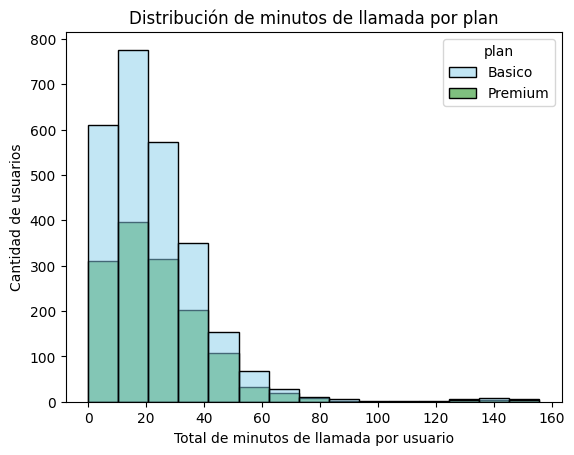

In [ ]:

# Histograma para visualizar la cant_minutos_llamada
palette=["skyblue","green"]
sns.histplot(
    data=user_profile, # seleccionamos el data frame user_profile
    x="cant_minutos_llamada", # se define en el eje X la cantidad de minutos
    hue="plan",        # mostrará la distribución de mensajes por tipo de plan
    bins=15,           #  √3999 = 63.24 → ≈63 bins, pero seria demasiado a graficar, nos quedaremos con 15 para mejorar la interpretación
    kde=False,         # Solo se mostrarán las barras de histograma sin curva de densidad
    multiple="layer",  # Se superponen distribuciones de cada plan en la misma gráfica
    palette=palette    # paleta de colores definida al inicio
)
plt.xlabel("Total de minutos de llamada por usuario")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de minutos de llamada por plan")
plt.show()

💡Insights:
- Distribución Right-skewed confirmada, cola hasta ~ 160 minutos, al parecer nadie está llegando a su tope
- No se generan cargos por excedentes
- Los usuarios están bien cubiertos en su plan actual

Como los usuarios no agotan ni sus mensajes ni su voz, el diferenciador puede radicar en los GB de datos. ¿Por qué alguien adquirirá el plan premium cuando el básico tiene todos los servicios que necesita?, la respuesta a la pregunta podria estar en los GB.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

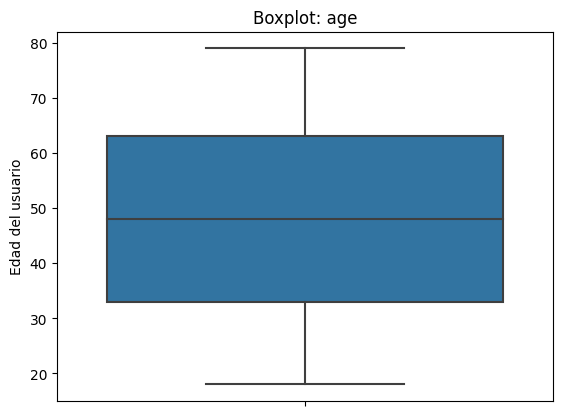

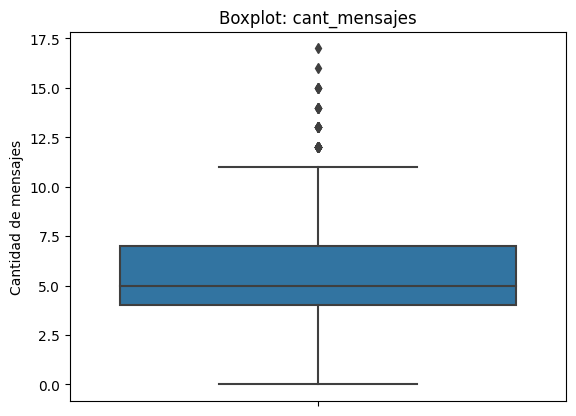

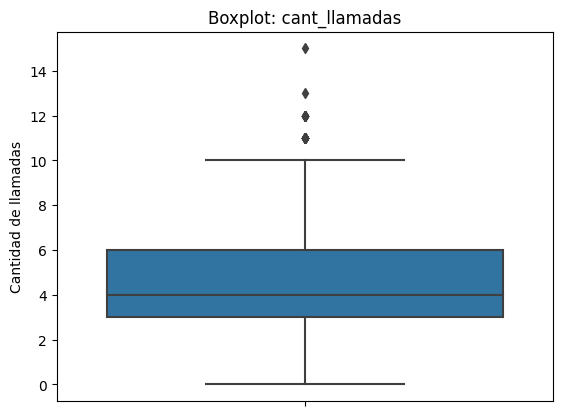

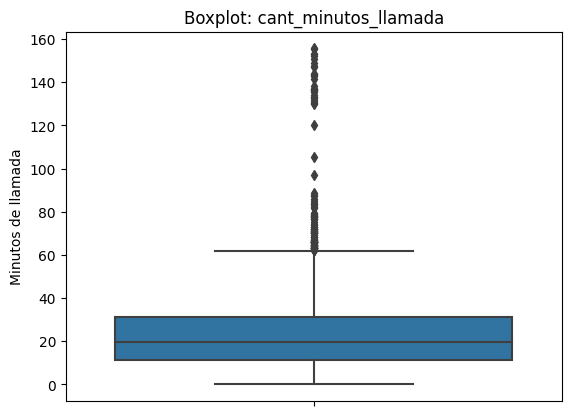

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# diccionario de correspondencia entre columna y etiqueta y
etiquetas_y = {
    "age": "Edad del usuario",
    "cant_mensajes": "Cantidad de mensajes",
    "cant_llamadas": "Cantidad de llamadas",
    "cant_minutos_llamada": "Minutos de llamada"
}

for col in columnas_numericas:
    sns.boxplot(y=user_profile[col])
    plt.title(f"Boxplot: {col}")
    plt.ylabel(etiquetas_y[col])
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: presenta valores atipicos leves (outliers), pero no se salen de su plan contratado
- cant_llamadas: presenta valores atipicos leves (outliers), pero no se salen de su plan contratado
- cant_minutos_llamada: presenta valores atipicos leves (outliers)

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas","cant_minutos_llamada"]
for col in columnas_limites:
    print("\n=== Rangos intercuartilicos ===")
    #calcular Q1
    Q1 = user_profile[col].quantile(0.25) # valor por debajo del cual se encuentra el 25% de los datos.
    print('Primer cuartil:', Q1)
    #calcular Q3
    Q3 = user_profile[col].quantile(0.75)       # valor por debajo del cual se encuentra el 75% de los datos.
    print('Tercer cuartil:', Q3)
    #calcular IQR
    IQR = Q3 - Q1                         # rango intercuartílico
    print("IQR de",col,":", IQR)
    # calcular límite inferior y superior

    limite_superior = Q3+1.5*IQR
    total_ls= (user_profile[col] > limite_superior).sum()
    print("Registros arriba del límite superior: ",total_ls)



=== Rangos intercuartilicos ===
Primer cuartil: 4.0
Tercer cuartil: 7.0
IQR de cant_mensajes : 3.0
Registros arriba del límite superior:  46

=== Rangos intercuartilicos ===
Primer cuartil: 3.0
Tercer cuartil: 6.0
IQR de cant_llamadas : 3.0
Registros arriba del límite superior:  30

=== Rangos intercuartilicos ===
Primer cuartil: 11.12
Tercer cuartil: 31.415
IQR de cant_minutos_llamada : 20.295
Registros arriba del límite superior:  109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()
# la siguiente linea nos da los datos estadisticos por plan
# user_profile.groupby("plan")[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- cant_mensajes: mantendria los outliers porque estan dentro del uso normal de los planes, 100 para básico y 500 para premium
- cant_llamadas: mantendria los outliers, porque 15 llamadas son posibles y reales
- cant_minutos_llamada: mantendria los outliers porque estan dentro del uso normal de los planes 100 para básico y 600 para premium, recomendaria filtrar los del plan básico que superan los 100 minutos para evaluar si conviene ofrecerles upgrade a premium o si conviene cobrarles minutos extras.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def segmentacion_clientes (row):
    if row["cant_llamadas"]<5 and row["cant_mensajes"]<5:
        return "Bajo uso"
    elif row["cant_llamadas"]<10 and row["cant_mensajes"]<10:
        return "Uso medio"
    else:
        return "Alto uso"
user_profile["grupo_uso"]=user_profile.apply(segmentacion_clientes, axis=1)
print(user_profile[["grupo_uso"]].value_counts(normalize=True))

grupo_uso
Uso medio    0.735934
Bajo uso     0.194549
Alto uso     0.069517
dtype: float64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def segmentacion_clientes_edad (row):
    if row["age"]<30:
        return "Joven"
    elif row["age"]<60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"]=user_profile.apply(segmentacion_clientes_edad, axis=1)
print(user_profile[["grupo_edad"]].value_counts(normalize=True))

grupo_edad  
Adulto          0.504376
Adulto Mayor    0.305576
Joven           0.190048
dtype: float64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

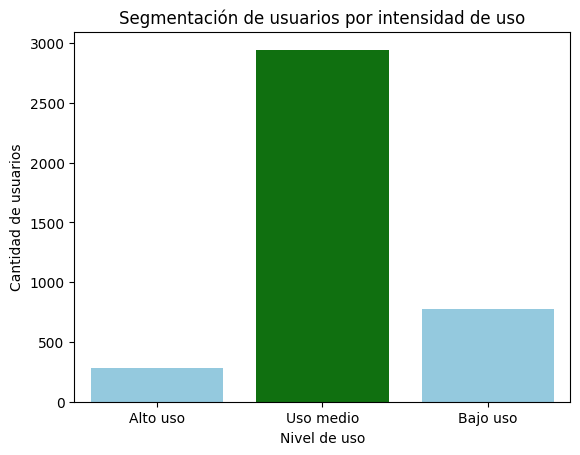

In [ ]:
# Visualización de los segmentos por uso
# Para la variable palette, se usa un diccionario de correspondencia entre categoría y color
# tonos naranjas para dar la sensación de "intensidad"
palette_uso = {
    "Bajo uso": "peachpuff",
    "Uso medio": "sandybrown",
    "Alto uso": "chocolate"
}
orden=["Alto uso","Uso medio","Bajo uso"]  # Lista de orden de segmentos de mayor a menor uso
sns.countplot(data=user_profile, x="grupo_uso", palette=palette, order=orden)
plt.title("Segmentación de usuarios por intensidad de uso")
plt.ylabel("Cantidad de usuarios")
plt.xlabel("Nivel de uso")
plt.show()

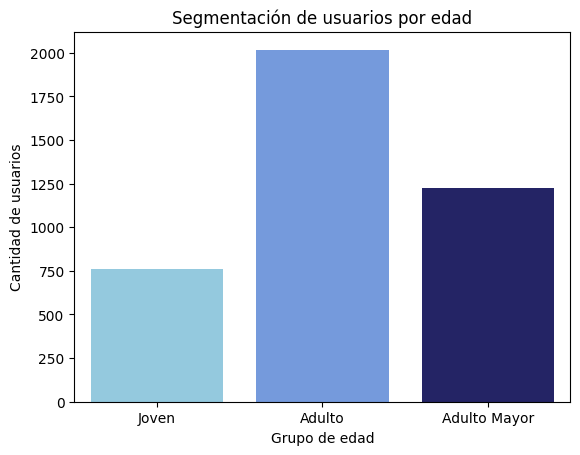

In [ ]:
# Visualización de los segmentos por edad
# Para la variable palette, se usa un diccionario de correspondencia entre categoría y color
# Debido a que este gráfico mide una dimensión diferente, se cambió la paleta a tonos azules elegantes para no confundir al stakeholder
palette = {
    "Joven": "skyblue",
    "Adulto": "cornflowerblue",
    "Adulto Mayor": "midnightblue"
}
# Es importante no cometer ningún error de digitación en el diccionario o la lista porque romperán el gráfico
# Si no se dispone de tiempo, entonces no conviene usar paleta con diccionario ni orden.
orden=["Joven","Adulto","Adulto Mayor"]  # Lista de orden de edades de mas joven a mayor edad
sns.countplot(data=user_profile, x="grupo_edad", palette=palette, order=orden)
plt.title("Segmentación de usuarios por edad")
plt.ylabel("Cantidad de usuarios")
plt.xlabel("Grupo de edad")
plt.show()

---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
    - Nulos
        - Churn_date 88% de nulos (ese porcentaje son los usuarios activos)
        - City 11% de nulos, reemplazados por "unknown"
        - Duration 44% y length 55%, relacionados con type, si un usuario llama entonces lenght es nulo y si un usuario manda mensaje de texto entonces duración de llamada es nulo
        - Date 0.1% de nulos, irrelevante.
    - Valores invalidos y sentinels
        - La columna age tenia 55 valores negativos inválidos (se corrigieron por la mediana), no hay menores de edad y la edad máxima es 79 años
        - Las columnas duration y lenght, sus registros suman 40,028, si el dataset tiene un total de 40,000 registros, entonces hay 28 anomalías
        - 16 registros donde "duration" tiene un valor de 120 segundos cuando "type" tiene el valor de "text" y "lenght" tiene valor
        - 12 registros donde "lenght" tiene un valor de 1490 caracteres cuando "type" tiene el valor de "call" y "duration" tiene valor
        - La columna city tenia 96 registros sin ciudad con el signo "?", reemplazados por unknown
        - En el caso de la fecha de registro (reg_date) va del año 2022 al 2024 y existen cuarenta registros inválidos del año 2026, que representan el 1% de los registros, estas fechas están fuera del rango esperado (hasta el 2024), se convirtieron a NaT para posteriormente excluirlos de cálculos relacionados con fechas
        - En el caso de la fecha de uso del servicio (date), únicamente hay registros del año 2024 con menos del 1% de valores nulos, se recomienda excluirlos de cálculos relacionados con fechas

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
    - 64.87 % de los usuarios usan plan Básico y 35.13% el plan Premium
    - La distribución de edades por plan es simétrica y  se comporta de forma similar en ambos planes, aunque en mayor proporción para plan básico, posiblemente por ser mas accesible.
    - Distribución Right-skewed confirmada para:
        - Cantidad de mensajes enviados
        - Cantidad de llamadas realizadas
        - Total de minutos de llamada por usuario
    - Sin embargo los usuarios no agotan ni sus mensajes ni su voz

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    - Adultos (30 a 59 años) con el 50% de los usuarios, que por la edad forman parte de la población econamicamente activa
    - Uso medio ( 5 a 9 mensajes y llamadas) con el 73% de los usuarios

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
    - Se encontraron valores atípicos leves (outliers) para:
        - Cantidad de mensajes, sin embargo están dentro del uso normal de los planes, 100 para básico y 500 para premium
        - Cantidad de llamadas: con un máximo de 15 llamadas que son posibles y reales
    - Total de minutos: outliers dentro del uso normal de los planes 100 para básico y 600 para premium, recomendaría filtrar los del plan básico que superan los 100 minutos para evaluar si conviene ofrecerles upgrade a premium o si conviene cobrarles minutos extras.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
    - El promedio de mensajes es 5.5, llamadas 4.4 y minutos usados 23.3, debido a que los usuarios no agotan ni sus mensajes, ni su voz, no se generan cargos por excedentes, por lo tanto el diferenciador puede radicar en los GB de datos, de otro modo ¿Por qué alguien adquirirá el plan premium cuando el básico tiene todos los servicios que necesita?, la respuesta a la pregunta podría estar en los GB.
    - Se sugiere obtener el consumo de datos para correlacionarlo con el plan básico y premium, segmentando por edades y consumo para crear planes promocionales y upgrades.


### Análisis ejecutivo
Conectatel cuenta con una base de usuarios estable, donde el 88% de sus usuarios estan activos y el 73% hace un uso medio de los servicios.

⚠️ **Problemas detectados en los datos**
- Nulos
  - Churn_date tiene 88% de nulos, ese porcentaje son los usuarios que estan activos
  - City 11% de nulos, reemplazados por "unknown"
  - Duration 44% y length 55%, relacionados con type, si un usuario llama entonces lenght es nulo y si un usuario manda mensaje de texto entonces duración de llamada es nulo
  - Date 0.1% de nulos, irrelevante.
- Valores invalidos y sentinels
  - La columna age tenia 55 valores negativos inválidos (se corrigieron por la mediana), no hay menores de edad y la edad máxima es 79 años
  - En las columnas duration y lenght hay 28 anomalías en las que una fila almacena valor para lenght y duration.
  - La columna city tenia 96 registros sin ciudad con el signo "?", reemplazados por unknown
  - La fecha de registro (reg_date) presento 1% de registros inválidos con el año 2026, se convirtieron a NaT para posteriormente excluirlos de cálculos relacionados con fechas

🔍 **Segmentos por Edad**
- El 50% de los usuarios son adultos (30 a 59 años), que es el grupo con mayor poder adquisitivo por ser la población económicamente activa
- Jóvenes representan del 19%, estos usuarios son estudiantes o están en su primer empleo, hacen mayor uso de datos y redes sociales

📊 **Segmentos por Nivel de Uso**
- El 73% de los usuarios hace un uso medio de los servicios
- Los usuarios envian 5.5 mensajes en promedio, llamadas 4.4 y minutos usados 23.3, nadie está excediendo los servicios de su plan.
- 35% de los usuarios son premium, hay margen para vender upgrade.

➡️ Esto sugiere que no exceden los servicios de su plan, porque estan haciendo uso de apps que consumen datos como Facebook, Instagram, Whatsapp, Telegram o Pulse que además de texto permiten enviar imágenes o videollamadas, por este motivo no se generan cargos por excedentes.

💡 **Recomendaciones**
- Implementar métricas de consumo de datos que permitan analizar el comportamiento y necesidades de los clientes.
- Diseñar planes tarifarios en función del uso de datos y redes sociales
- Promociones especiales para los jovenes, hacen mayor uso de datos y conectividad por lo tanto estan mas dispuestos a pagar más por ello


Link a repositorio público del proyecto: `https://github.com/pedrodavidreyes/Analisis_Conectatel_SP7`